In [1]:
# Mounting G-Drive
from google.colab import drive
drive.mount('/content/drive')


# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [2]:
# Paths for Dataset

data_dir = '/content/drive/My Drive/Lung Disease Dataset'
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"


In [3]:
# 4. Transforms and dataloaders
img_size = 224
batch_size = 32

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_data.classes
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


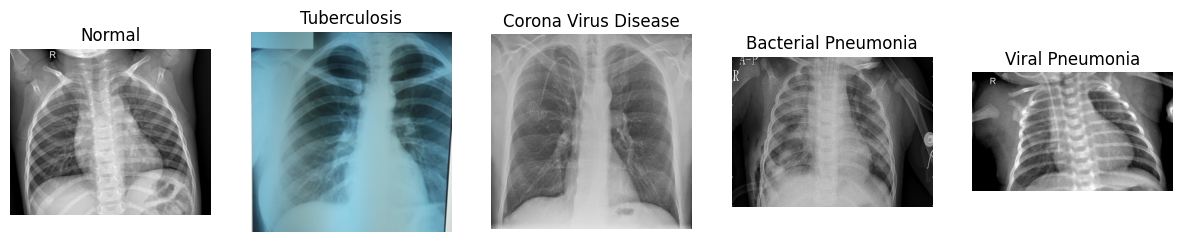

In [4]:
# 5. Visualize a sample image per class (optional, comment out if not needed)
import os
from PIL import Image

plt.figure(figsize=(15,6))
class_dirs = [os.path.join(train_dir, cls) for cls in os.listdir(train_dir)]
for idx, class_dir in enumerate(class_dirs):
    img_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_file)
    img = Image.open(img_path)
    plt.subplot(1, 5, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(os.path.basename(class_dir))
    plt.axis('off')
plt.show()

In [5]:
# 6. Model: DenseNet121 pretrained, classifier modified
model = models.densenet121(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # Freeze all layers

model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 66.1MB/s]


In [6]:
# 7. Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 8. Training loop
epochs = 10
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels).item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_densenet_model.pth")

    scheduler.step()

Epoch 1/10 - Loss: 1.2131 - Val Acc: 0.7426
Epoch 2/10 - Loss: 0.8022 - Val Acc: 0.7897
Epoch 3/10 - Loss: 0.6642 - Val Acc: 0.7892
Epoch 4/10 - Loss: 0.5985 - Val Acc: 0.8189
Epoch 5/10 - Loss: 0.5657 - Val Acc: 0.7996
Epoch 6/10 - Loss: 0.5335 - Val Acc: 0.8120
Epoch 7/10 - Loss: 0.5329 - Val Acc: 0.8120
Epoch 8/10 - Loss: 0.5328 - Val Acc: 0.8234
Epoch 9/10 - Loss: 0.5369 - Val Acc: 0.8204
Epoch 10/10 - Loss: 0.5194 - Val Acc: 0.8194


In [8]:
# 9. Load best model & test evaluation
model.load_state_dict(torch.load("best_densenet_model.pth"))
model.eval()
test_correct = 0
test_preds = []
test_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_correct += torch.sum(preds == labels).item()
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
test_acc = test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8158


Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.70      0.72      0.71       403
Corona Virus Disease       0.89      0.95      0.92       407
              Normal       0.81      0.94      0.87       404
        Tuberculosis       0.97      0.88      0.92       408
     Viral Pneumonia       0.70      0.60      0.64       403

            accuracy                           0.82      2025
           macro avg       0.81      0.82      0.81      2025
        weighted avg       0.82      0.82      0.81      2025



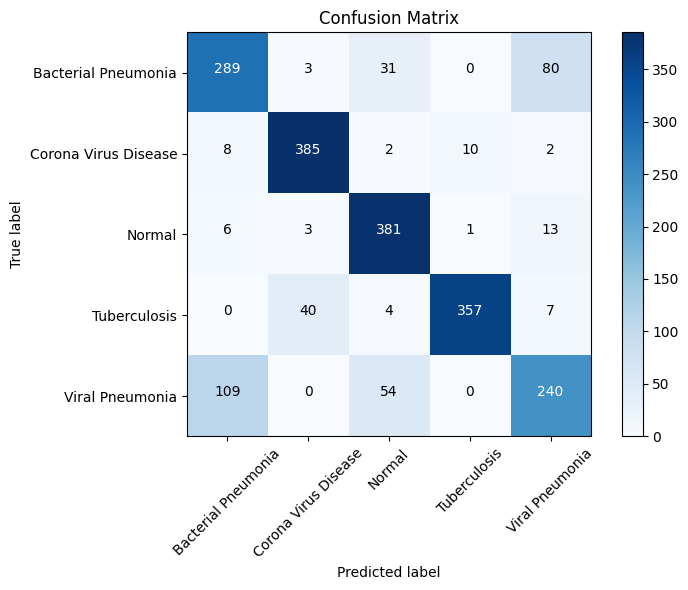

In [9]:
# 10. Classification report & confusion matrix
print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(test_labels, test_preds)
plot_confusion_matrix(cm, class_names, title='Confusion Matrix')
plt.show()